In [ ]:
!pip install geopandas rasterio contextily pulp shapely

In [3]:
import sys, os

# ensure Python can see your MILP folder
sys.path.append(os.path.abspath("../"))  # one level up from your notebook

# now import the function
import MILP.distance_optimizer
import importlib
importlib.reload(MILP.distance_optimizer)  # reloads updated .py file
from MILP.distance_optimizer import optimize_shade_placement


import pandas as pd
import geopandas as gpd
import numpy as np
import contextily as cx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pulp import *

In [25]:
# --- Load all data ---

# Raw Data
bus_stops = gpd.read_file("../../461/data/bus_stops.geojson").to_crs(3857)
major_transit_stops = gpd.read_file("../../data/preprocessed/la_major_transit_stops_la.geojson").to_crs(3857)
schools = gpd.read_file("../../data/raw/la_schools_colleges_universities.geojson").to_crs(3857)
hospitals = gpd.read_file("../../data/raw/la_hospitals_clinics_live.geojson").to_crs(3857)
food = gpd.read_file("../../data/raw/la_food_assistance.geojson").to_crs(3857)
city_boundaries = gpd.read_file("../../data/raw/la_city_boundaries.geojson").to_crs(3857)

# DTLA Data
bus_stops_dtla = gpd.read_file("../../data/preprocessed/bus_stops_dtla.geojson").to_crs(3857)
major_transit_stops_dtla = gpd.read_file("../../data/preprocessed/la_major_transit_stops_dtla.geojson").to_crs(3857)
schools_dtla = gpd.read_file("../../data/preprocessed/la_schools_dtla.geojson").to_crs(3857)
hospitals_dtla = gpd.read_file("../../data/preprocessed/la_hospitals_clinics_dtla.geojson").to_crs(3857)
food_dtla = gpd.read_file("../../data/preprocessed/la_food_assistance_dtla.geojson").to_crs(3857)

# Inglewood Data
bus_stops_inglewood = gpd.read_file("../../data/preprocessed/bus_stops_inglewood.geojson").to_crs(3857)
schools_inglewood = gpd.read_file("../../data/preprocessed/schools_inglewood.geojson").to_crs(3857)
hospitals_inglewood = gpd.read_file("../../data/preprocessed/hospitals_inglewood.geojson").to_crs(3857)
food_inglewood= gpd.read_file("../../data/preprocessed/food_assistance_inglewood.geojson").to_crs(3857)

# Heat and Socioeconomic Layers extracted from UCLA Shade Mapping
ucla_shade_heat = gpd.read_file("../../data/layers/heat_layer.geojson").to_crs(3857)
ucla_shade_socio = gpd.read_file("../../data/layers/socioeconomic_layer.geojson").to_crs(3857)

# --- Combine all public service facilities ---
public_points_dtla = gpd.GeoDataFrame(pd.concat(
    [schools_dtla[['geometry']], hospitals_dtla[['geometry']], food_dtla[['geometry']]],
    ignore_index=True), crs=schools_dtla.crs)
public_points_inglewood = gpd.GeoDataFrame(pd.concat(
    [schools_inglewood[['geometry']], hospitals_inglewood[['geometry']], food_inglewood[['geometry']]],
    ignore_index=True), crs=schools_inglewood.crs)

# --- Combine heat and shade layers with bus stops ---
processed_shade_stops = gpd.sjoin(major_transit_stops_dtla, ucla_shade_heat, how = 'left')
processed_shade_stops = processed_shade_stops.drop(columns=['index_right'])
processed_shade_stops = gpd.sjoin(processed_shade_stops, ucla_shade_socio, how = 'left')
print(processed_shade_stops.columns)

# --- Add together heat and socioeconomic layers to visualize point priority by these 2 objectives
processed_shade_stops['heat_socio_layer'] = (
    processed_shade_stops['heat_layer'] + processed_shade_stops['socioeconomic_layer']
)

Index(['OBJECTID', 'stop_id', 'route_count', 'route_stop', 'lat', 'lon',
       'geometry', 'heat_layer', 'index_right', 'socioeconomic_layer'],
      dtype='object')


Bus Stops vs. Major Transit Stops

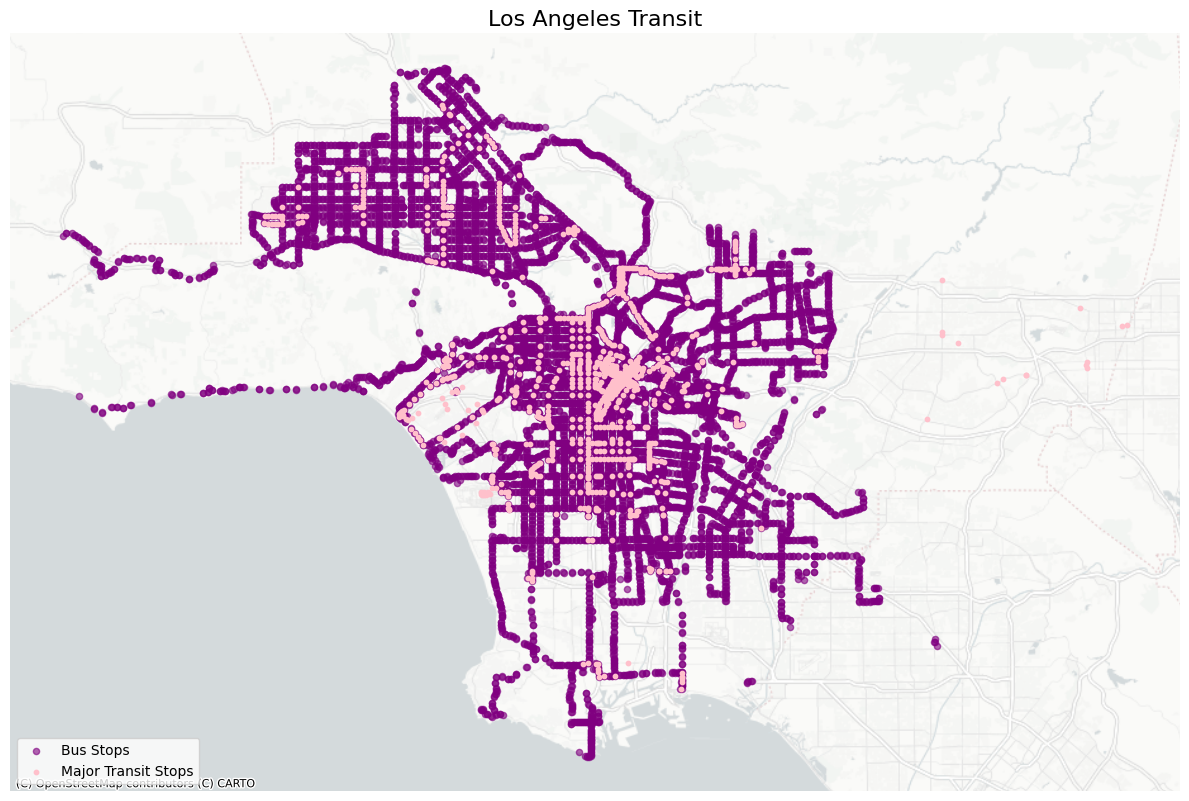

In [26]:
# Visualize bus stops for possible shade placements
# Make sure both layers use the same projection (Web Mercator for basemap)
bus_stops = bus_stops.to_crs(epsg=3857)
major_transit_stops = major_transit_stops.to_crs(epsg=3857)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all bus stops in light purple (lower zorder so they're underneath)
bus_stops.plot(ax=ax, color='purple', markersize=20, alpha=0.6, label='Bus Stops', zorder=1)

# Plot major transit stops (la county) in orange (on top)
major_transit_stops.plot(ax=ax, color='pink', markersize=10,
                         label='Major Transit Stops', zorder=2)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Style tweaks
ax.set_axis_off()
ax.set_title('Los Angeles Transit', fontsize=16)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

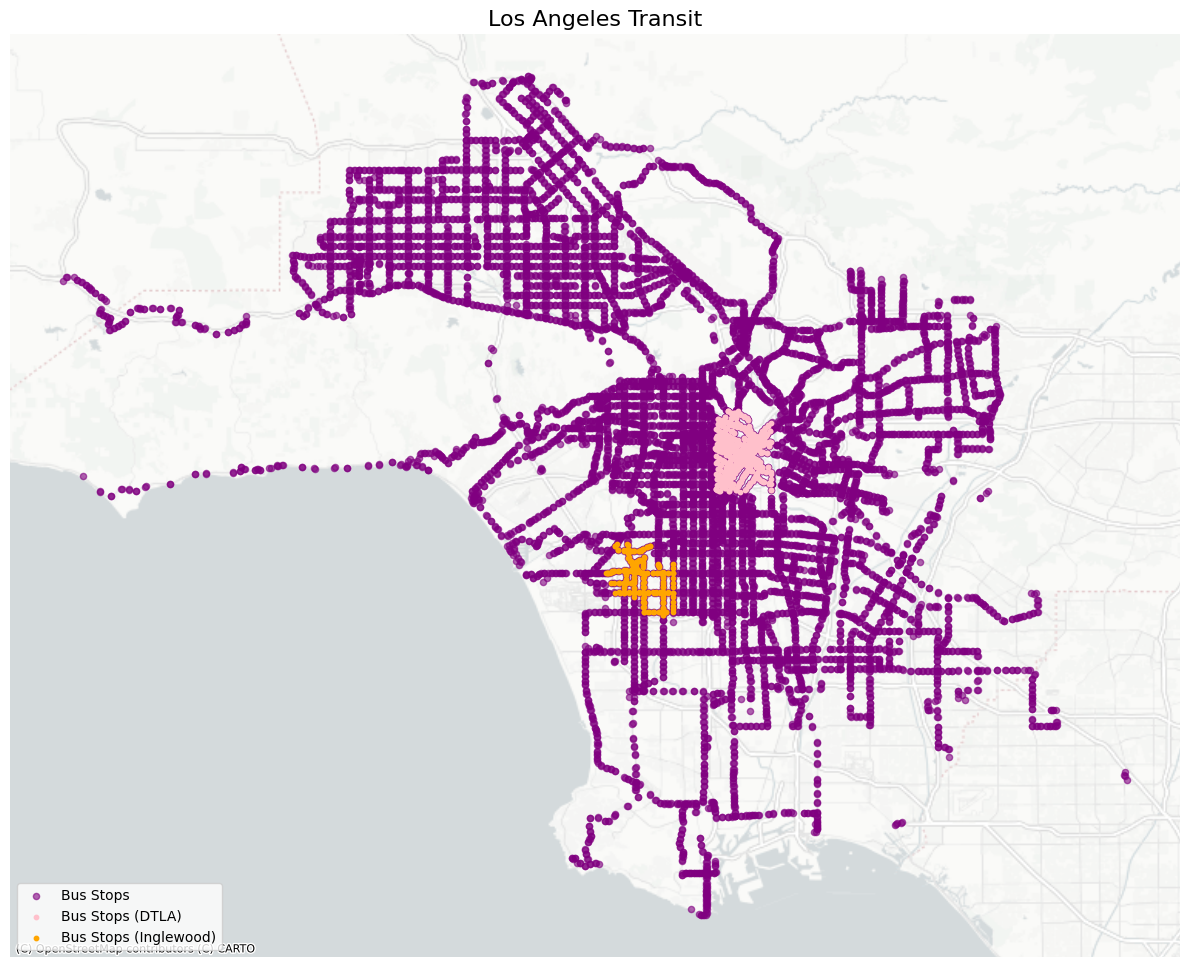

In [29]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all bus stops in light purple (lower zorder so they're underneath)
bus_stops.plot(ax=ax, color='purple', markersize=20, alpha=0.6, label='Bus Stops', zorder=1)

# Plot bus stops in dtla in orange (on top)
bus_stops_dtla.plot(ax=ax, color='pink', markersize=10,
                         label='Bus Stops (DTLA)', zorder=2)

# Plot bus stops in inglewood in orange (on top)
bus_stops_inglewood.plot(ax=ax, color='orange', markersize=10,
                         label='Bus Stops (Inglewood)', zorder=3)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Style tweaks
ax.set_axis_off()
ax.set_title('Los Angeles Transit', fontsize=16)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Food, School, Hospital Public Service Graphs

/var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/ipykernel_81646/4286413885.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  hospitals_dtla.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals (DTLA)', zorder=4)
/var/folders/wl/c3pz93w50hz8v01l8clvl_qc0000gn/T/ipykernel_81646/4286413885.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  hospitals_inglewood.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals', zorder=4)


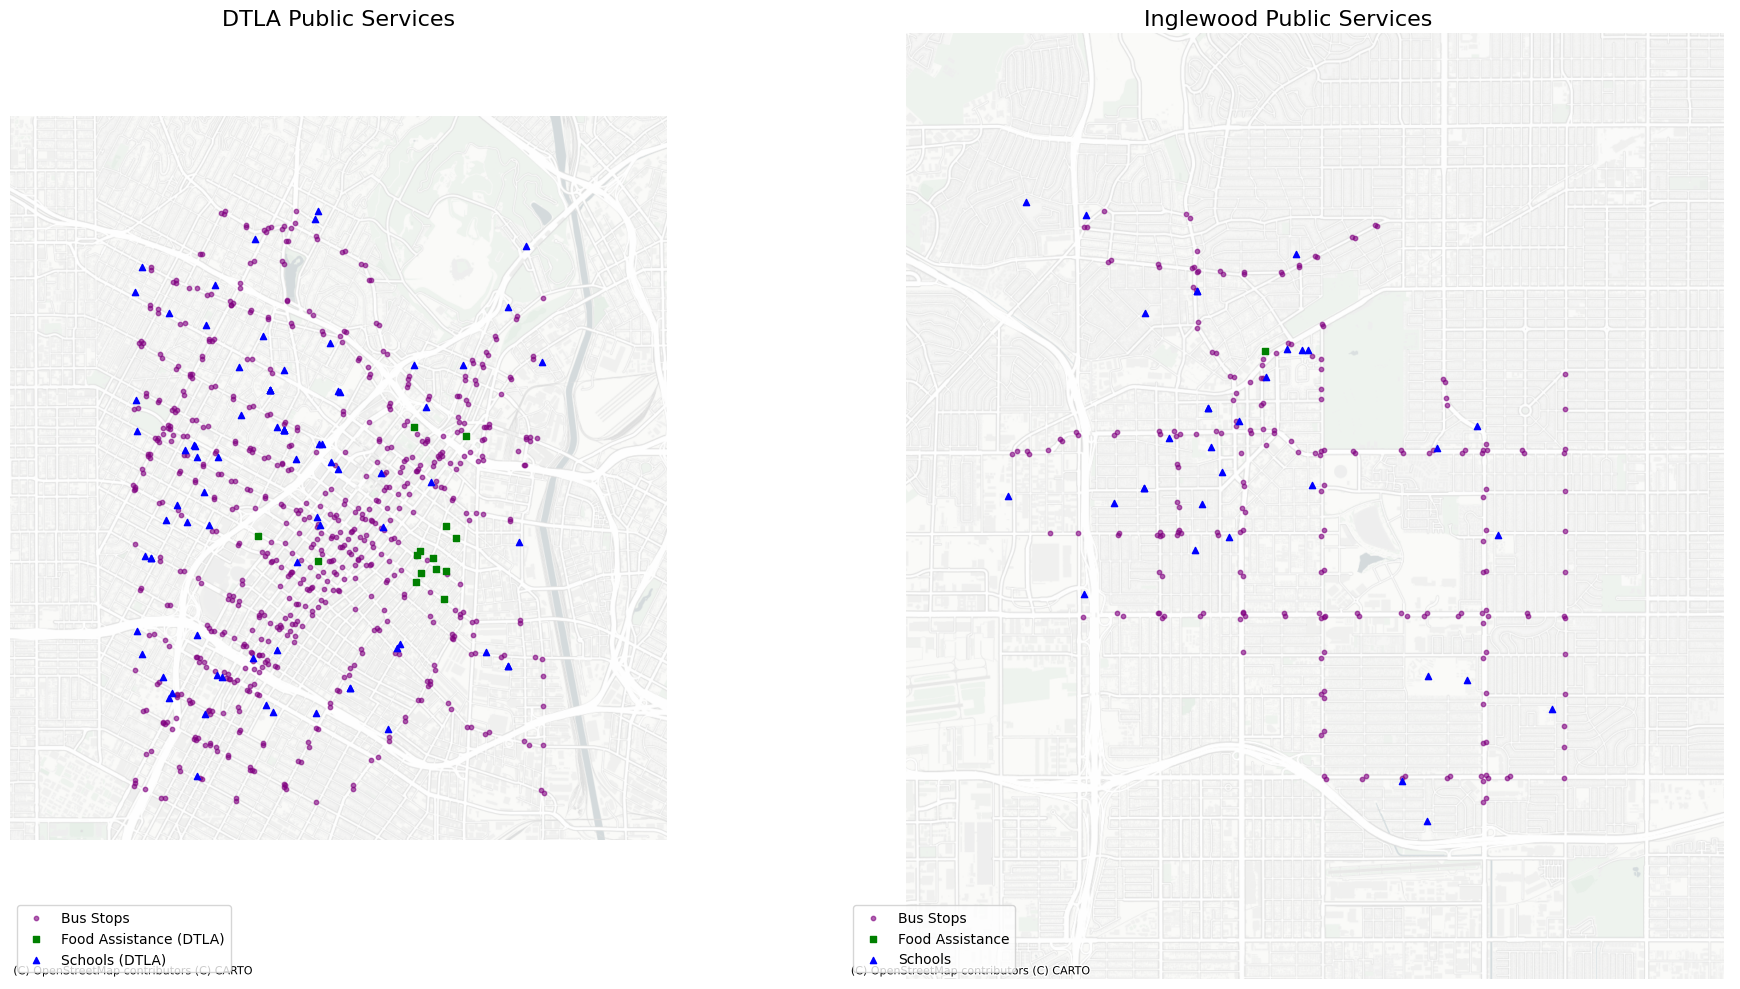

In [39]:
import matplotlib.pyplot as plt
import contextily as cx

# Make sure all layers use the same projection (Web Mercator)
layers = [food_dtla, schools_dtla, hospitals_dtla, bus_stops]
for gdf in layers:
    gdf.to_crs(epsg=3857, inplace=True)

# Also project Inglewood layers
food_inglewood = food_inglewood.to_crs(epsg=3857)
schools_inglewood = schools_inglewood.to_crs(epsg=3857)
hospitals_inglewood = hospitals_inglewood.to_crs(epsg=3857)
bus_stops_inglewood = bus_stops_inglewood.to_crs(epsg=3857)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# -------------------- DTLA --------------------
ax = axes[0]
bus_stops_dtla.plot(ax=ax, color='purple', markersize=10, alpha=0.6, label='Bus Stops', zorder=1)
food_dtla.plot(ax=ax, color='green', markersize=20, marker='s', label='Food Assistance (DTLA)', zorder=4)
schools_dtla.plot(ax=ax, color='blue', markersize=20, marker='^', label='Schools (DTLA)', zorder=4)
hospitals_dtla.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals (DTLA)', zorder=4)

cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Zoom to DTLA area
minx, miny, maxx, maxy = bus_stops_dtla.total_bounds
padding_val = 0.3
x_pad = (maxx - minx) * padding_val
y_pad = (maxy - miny) * padding_val
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

ax.set_axis_off()
ax.set_title("DTLA Public Services", fontsize=16)
ax.legend(loc='lower left')

# -------------------- Inglewood --------------------
ax = axes[1]
bus_stops_inglewood.plot(ax=ax, color='purple', markersize=10, alpha=0.6, label='Bus Stops', zorder=1)
food_inglewood.plot(ax=ax, color='green', markersize=20, marker='s', label='Food Assistance', zorder=4)
schools_inglewood.plot(ax=ax, color='blue', markersize=20, marker='^', label='Schools', zorder=4)
hospitals_inglewood.plot(ax=ax, color='red', markersize=20, marker='D', label='Hospitals', zorder=4)

cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)

# Zoom to Inglewood area
minx, miny, maxx, maxy = bus_stops_inglewood.total_bounds
x_pad = (maxx - minx) * padding_val
y_pad = (maxy - miny) * padding_val
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

ax.set_axis_off()
ax.set_title("Inglewood Public Services", fontsize=16)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()


Run MILP Optimizer

In [ ]:
# --- Run the MILP optimizer ---
optimized_shades = optimize_shade_placement(
    candidate_points=processed_shade_stops,
    public_points=public_points_dtla,
    max_shades=30,
    use_spacing=True,
    use_public=True,
    use_heat=True,
    use_socioeconomic=True,
    spacing_threshold=500,
    public_service_threshold=300,
)

print(f"Selected {len(optimized_shades)} optimal shade sites.")

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot the first graph visualizing optimal shade locations against proximity to public service buildings
major_transit_stops_dtla.plot(ax=axes[0], color='orange', label='Transit Stops', alpha=0.5)
public_points.plot(ax=axes[0], color='gray', label='Public Facilities', alpha=0.4)
optimized_shades.plot(ax=axes[0], color='purple', marker='*', markersize=120, alpha = 0.4, label='Optimal Shade Locations')

cx.add_basemap(axes[0], source=cx.providers.CartoDB.PositronNoLabels)
axes[0].legend()
axes[0].set_title("DTLA Shade Placement Optimization (MILP)", fontsize=16)
axes[0].set_axis_off()

# Plot the second graph visualizing heat and socioeconomic priority layers
processed_shade_stops.plot(
    ax=axes[1],
    cmap = 'YlOrRd',
    column="heat_socio_layer",
    markersize=50,
    alpha=0.7
)
optimized_shades.plot(ax=axes[1], color='purple', marker='*', markersize=120, alpha=0.4, label='Optimal Shade Locations')
cx.add_basemap(axes[1], source=cx.providers.CartoDB.PositronNoLabels)
axes[1].set_title("Transit Stops Colored by Heat + Socioeconomic Layer", fontsize=16)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()